In [2]:
import pandas as pd
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import root_mean_squared_error
import os
os.chdir("C:/Users/PGCP-AI/ML/MachineLearning/Datasets")

In [3]:
df = pd.read_csv('AusGas.csv')
df.columns

Index(['Month', 'GasProd'], dtype='object')

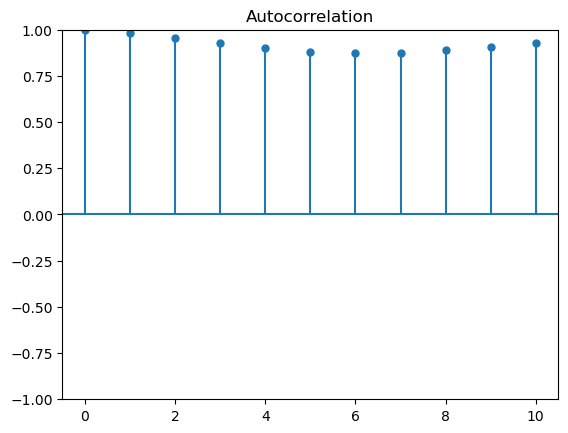

In [4]:
plot_acf(df['GasProd'],lags=10,alpha=None)
plt.show()

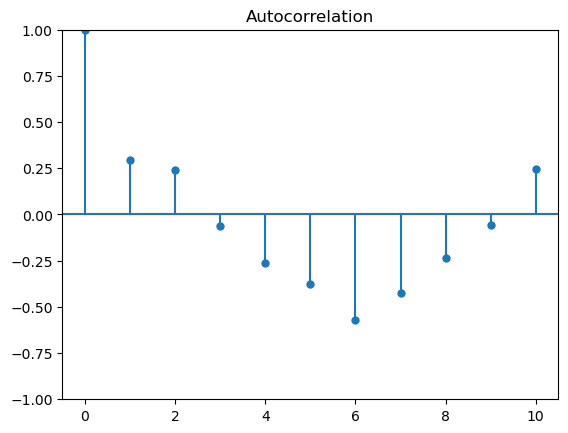

In [6]:
diff1 = df["GasProd"].diff().iloc[1:]
plot_acf(diff1,lags=10,alpha=None)
plt.show()

In [7]:
result = adfuller(df['GasProd'], maxlag=10)
print("P-Value =", result[1])
if result[1] < 0.05:
    print("Time Series is Stationary")
else:
    print("Time Series is not Stationary")

P-Value = 0.9981674130928889
Time Series is not Stationary


In [8]:
diff = df["GasProd"].diff().iloc[1:]
result = adfuller(diff, maxlag=10)
print("P-Value =", result[1])
if result[1] < 0.05:
    print("Time Series is Stationary")
else:
    print("Time Series is not Stationary")

P-Value = 2.1511188581891522e-29
Time Series is Stationary


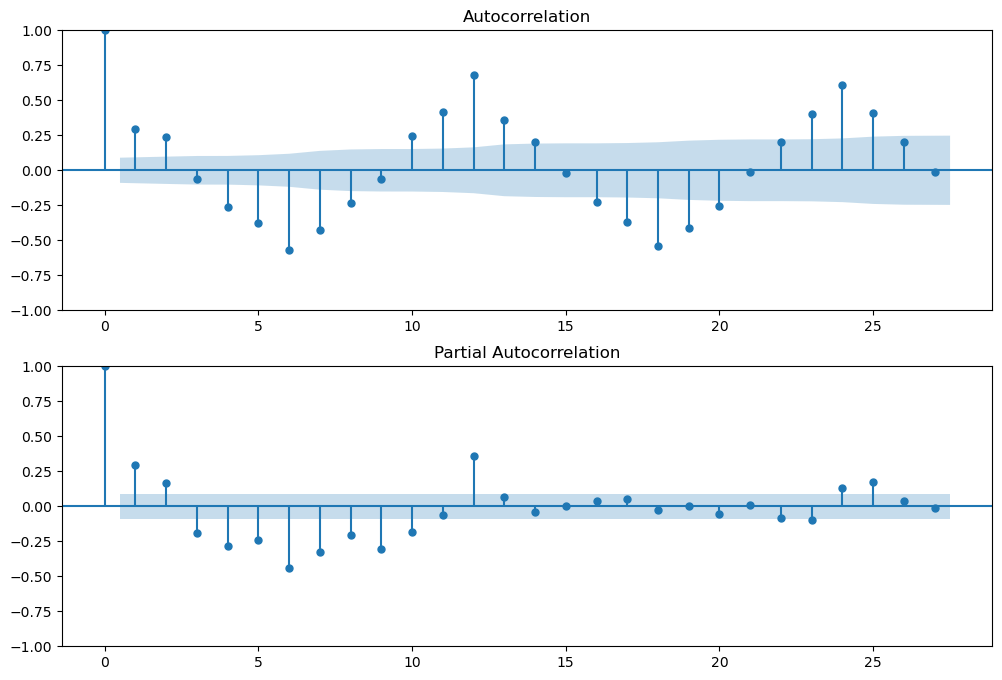

In [10]:
fig, ax = plt.subplots(2, 1, figsize = (12,8))
plot_acf(diff, ax = ax[0])
plot_pacf(diff, ax = ax[1])
plt.show()

In [11]:
y_train = df['GasProd'].iloc[:-12]
y_test = df['GasProd'].iloc[-12:]

In [12]:
model = ARIMA(y_train, order = (1,1,2))
model_fit = model.fit()
print("Coefficients: %s" % model_fit.params)

Coefficients: ar.L1     7.765128e-01
ma.L1    -6.680617e-01
ma.L2    -2.525748e-01
sigma2    6.249294e+06
dtype: float64


In [13]:
predictions = model_fit.predict(start = len(y_train), end = len(y_train) + len(y_test) -1, dynamic = False)
root_mean_squared_error(y_test, predictions)

10304.744937436482

In [14]:
model = ARIMA(y_train)
model_fit = model.fit()
print("Coefficients: %s" % model_fit.params)

Coefficients: const     2.062608e+04
sigma2    1.533778e+11
dtype: float64
